In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch.optim as optim
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn

from sklearn.preprocessing import LabelEncoder

from models.mlp import BlackBoxModel
from models.rbf import RBFNet
from models.svm import LinearSVM
from utils.datasets import dataset_loader

pd.set_option('display.max_columns', None)

%reload_ext autoreload
%autoreload 2

In [2]:
def bold(string):
    return "\033[1m" + string + "\033[0m"

In [ ]:
from data_loader.compas import CompasData
seed = 42
data = CompasData(seed=seed)
dataset_name = "compas"

# 为了兼容后续代码，保留 dataset 变量
dataset = data

In [4]:
dataset.data

,Sex = Female,Sex = Male,Age_Cat = Less than 25,Age_Cat = 25 - 45,Age_Cat = Greater than 45,Race = African-American,Race = Asian,Race = Caucasian,Race = Hispanic,Race = Native American,Race = Other,C_Charge_Degree = F,C_Charge_Degree = M,Priors_Count,Time_Served,Status
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,10.0,0.0
2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,1.0,0.0
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,14.0,6.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6167,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
6168,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
6169,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
6170,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,1.0


In [5]:
print("Testing COMPAS dataset with CompasData class...")
try:
    X_train, X_test, y_train, y_test = data.get_train_test()
    
    # 为了兼容，计算 mean 和 std (已在 CompasData 中完成)
    mean = data.mean
    std = data.std
    
    prop1s = round(np.average(y_train)*100, 2)
    print("✅ COMPAS dataset: SUCCESS")
    print(f"   X_train shape: {X_train.shape}, dtype: {X_train.dtypes.unique()}")
    print(f"   y_train shape: {y_train.shape}, dtype: {y_train.dtype}")
    print(f"   Mean shape: {mean.shape}")  
    print(f"   Std shape: {std.shape}")
    print(bold("Proportion of 1s in Training Data:") + " {}%".format(prop1s))
    
    # Test PyTorch tensor conversion
    print("\nTesting PyTorch tensor conversion...")
    import torch
    X_train_tensor = torch.FloatTensor(X_train.values)
    y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
    X_test_tensor = torch.FloatTensor(X_test.values)
    y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)
    print("✅ PyTorch conversion: SUCCESS")
    print(f"   X_train_tensor shape: {X_train_tensor.shape}")
    print(f"   y_train_tensor shape: {y_train_tensor.shape}")
    
except Exception as e:
    print(f"❌ COMPAS dataset: FAILED - {e}")
    import traceback
    traceback.print_exc()

Testing COMPAS dataset with CompasData class...
✅ COMPAS dataset: SUCCESS
   X_train shape: (4937, 15), dtype: [dtype('float64')]
   y_train shape: (4937,), dtype: float64
   Mean shape: (15,)
   Std shape: (15,)
Proportion of 1s in Training Data: 54.28%

Testing PyTorch tensor conversion...
✅ PyTorch conversion: SUCCESS
   X_train_tensor shape: torch.Size([4937, 15])
   y_train_tensor shape: torch.Size([4937, 1])


In [6]:
# Convert to DataFrames with proper column names for display purposes
# Note: data.features now includes target, so we need to exclude it for X
feature_cols = [f for f in data.features if f != data.target_name]
X = pd.DataFrame(X_train, columns=feature_cols)
print(bold("Dataset:") + " {}\n".format(dataset_name.replace('_', ' ').title()))
print(f"✅ Data types - X_train: {X_train.dtypes.unique()}, y_train: {y_train.dtype}")
X

Dataset: Compas

✅ Data types - X_train: [dtype('float64')], y_train: float64


,Sex = Female,Sex = Male,Age_Cat = Less than 25,Age_Cat = 25 - 45,Age_Cat = Greater than 45,Race = African-American,Race = Asian,Race = Caucasian,Race = Hispanic,Race = Native American,Race = Other,C_Charge_Degree = F,C_Charge_Degree = M,Priors_Count,Time_Served
4586,-0.482350,0.482350,-0.521574,0.859204,-0.516859,-1.038096,-0.075516,1.411925,-0.300514,-0.040283,-0.246105,-1.352352,1.352352,-0.692717,-0.314456
5160,-0.482350,0.482350,-0.521574,0.859204,-0.516859,-1.038096,-0.075516,-0.708110,-0.300514,-0.040283,4.062481,0.739303,-0.739303,-0.481336,-0.292653
4271,-0.482350,0.482350,-0.521574,0.859204,-0.516859,-1.038096,-0.075516,1.411925,-0.300514,-0.040283,-0.246105,-1.352352,1.352352,1.632482,-0.270850
978,-0.482350,0.482350,1.916884,-1.163633,-0.516859,-1.038096,-0.075516,1.411925,-0.300514,-0.040283,-0.246105,-1.352352,1.352352,-0.481336,-0.314456
5171,-0.482350,0.482350,-0.521574,0.859204,-0.516859,-1.038096,-0.075516,1.411925,-0.300514,-0.040283,-0.246105,-1.352352,1.352352,-0.692717,-0.314456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,-0.482350,0.482350,1.916884,-1.163633,-0.516859,-1.038096,-0.075516,1.411925,-0.300514,-0.040283,-0.246105,0.739303,-0.739303,-0.481336,0.012591
5191,-0.482350,0.482350,-0.521574,0.859204,-0.516859,0.963107,-0.075516,-0.708110,-0.300514,-0.040283,-0.246105,0.739303,-0.739303,-0.481336,-0.314456
5226,-0.482350,0.482350,-0.521574,0.859204,-0.516859,-1.038096,-0.075516,-0.708110,3.326960,-0.040283,-0.246105,-1.352352,1.352352,-0.058572,-0.314456
5390,2.072761,-2.072761,1.916884,-1.163633,-0.516859,-1.038096,-0.075516,1.411925,-0.300514,-0.040283,-0.246105,0.739303,-0.739303,-0.692717,-0.074622


In [7]:
# B_name = 'dnn'  # 'lr' or 'dnn' or 'xgb'
# if B_name == 'dnn':
#     from models.models_global_ce import dnn_normalisers as normalisers
# elif B_name == 'lr':
#     from models.models_global_ce import lr_normalisers as normalisers
# else:  # no xgb normalisation
#     normalisers = {name: False}
# normalise = [mean, std] if normalisers[name] else None

In [8]:
# import pickle
# with open('data/models_global_ce/{}_{}.pkl'.format(name, B_name), 'rb') as f:
#     B = pickle.load(f)

In [9]:
# print(bold("Dataset:") + " {}".format(name.replace('_', ' ').title()))
# print(bold("Model:") + " {}\n".format(B_name.replace('_', ' ').upper()))
# performance(B, x_train, x_test, y_train, y_test, normalise=normalise)

In [10]:
target_name = 'Status'  # Updated to match CompasData structure
dropped_features = []  # No dropped features for COMPAS

In [11]:
seed = 42

np.random.seed(seed)  # for reproducibility

# CompasData already handles standardization and type conversion
# Just ensure data types are correct for PyTorch
X_train = X_train.values.astype(float)
X_test = X_test.values.astype(float)
y_train = y_train.values.astype(float)
y_test = y_test.values.astype(float)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

# Initialize the model, loss function, and optimizer
# model = BlackBoxModel(input_dim=X_train.shape[1])
# model = RBFNet(input_dim=X_train.shape[1], hidden_dim=X_train.shape[1])
model = LinearSVM(input_dim=X_train.shape[1])

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
num_epochs = 300
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Evaluate on test set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)

    # Convert outputs to binary using 0.5 as threshold
    y_pred_tensor = (test_outputs > 0.5).float()
    correct_predictions = (y_pred_tensor == y_test_tensor).float().sum()
    accuracy = correct_predictions / y_test_tensor.shape[0]

accuracy.item()

0.6518218517303467

In [12]:
sample_num = 100
# Note: data.features now includes target, so we need to exclude it for X
feature_cols = [f for f in data.features if f != data.target_name]
X_test = pd.DataFrame(X_test, columns=feature_cols)

# Create unstandardized version by using the same indices from X_test
# Since train_test_split was done on reset indices, we can directly use iloc
X_test_raw = data.X_raw.iloc[X_test.index][feature_cols]  # Use iloc to avoid index issues
X_test_raw.index = X_test.index  # Ensure indices match

# Fixed indices for test purpose (same pattern as HELOC baseline)
indice = pd.Index([ 753,  582,  548,  113,  174,  420,  309,  998,  413, 1054, 1171,
             275,  771, 1135,  415,  478,  609,  168,  332,  933,  490,  906,
            1073,  128,  107, 1136,   43, 1168,  327,  610,  596,  631, 1205,
             534,  597,  220,  911,  198,  743,  985,  231,  865, 1088,  715,
             306,  101,  438,   78, 1223,   49,  936,  736,  243,  868, 1096,
             937,  381,  767,   63,  323,   44,  943, 1098,  482,  575,  254,
             529,  286,  992,  123,   76,  218, 1110,  545,  292,  701, 1226,
             844,  363,  811,  754,  266,  904,  958,  590, 1222,  233,   70,
             566,   23,  155,  707,   58,  428, 1008, 1057,  342,  629,   81,
            1127],
           dtype='int64')

# Map the indices to the actual test set indices (since train_test_split reorders)
available_test_indices = X_test.index.tolist()
# Select the first available indices up to sample_num
selected_indices = available_test_indices[:sample_num]

df_explain = X_test.loc[selected_indices]
df_explain_raw = X_test_raw.loc[selected_indices]  # Unstandardized version for AReS

y_test = pd.Series(y_test.reshape(-1))
y_true = y_test.loc[selected_indices]

y = model(torch.FloatTensor(df_explain.values))

print(f"✅ Sample selection completed")
print(f"📊 Selected {len(df_explain)} samples")
print(f"📈 Data shape: {df_explain.shape}")
print(f"🔍 Sample indices: {selected_indices[:10]}... (showing first 10)")
print(f"🔍 Raw data shape: {df_explain_raw.shape}")
print(f"🔍 Raw data sample:\n{df_explain_raw.head(3)}")

✅ Sample selection completed
📊 Selected 100 samples
📈 Data shape: (100, 15)
🔍 Sample indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]... (showing first 10)
🔍 Raw data shape: (100, 15)
🔍 Raw data sample:
   Sex = Female  Sex = Male  Age_Cat = Less than 25  Age_Cat = 25 - 45  \
0           0.0         1.0                     0.0                0.0   
1           0.0         1.0                     0.0                1.0   
2           0.0         1.0                     1.0                0.0   

   Age_Cat = Greater than 45  Race = African-American  Race = Asian  \
0                        1.0                      0.0           0.0   
1                        0.0                      1.0           0.0   
2                        0.0                      1.0           0.0   

   Race = Caucasian  Race = Hispanic  Race = Native American  Race = Other  \
0               0.0              0.0                     0.0           1.0   
1               0.0              0.0                     0.0        

In [13]:
df_compare = pd.DataFrame({
    "y_true": y_true.values,
    "y_pred": y.detach().numpy().squeeze()  
})

df_compare.head(50)

,y_true,y_pred
0,0.0,0.246953
1,1.0,0.691278
2,1.0,0.543525
3,1.0,0.552604
4,1.0,0.523370
5,1.0,0.661968
6,0.0,0.601838
7,0.0,0.423743
8,0.0,0.542990
9,1.0,0.683123


In [14]:
def postprocessing(counterfactual_X):

    prior_count_col = counterfactual_X['Priors_Count']
    time_served_col = counterfactual_X['Time_Served']
    counterfactual_X = (counterfactual_X>0.5).replace({False:0 ,True:1})
    counterfactual_X['Priors_Count'] = prior_count_col
    counterfactual_X['Time_Served'] = time_served_col
    
    return counterfactual_X

## GLOBE_CE

In [15]:
from explainers.globe_ce import GLOBE_CE

In [16]:
normalise = None

# AReS initiated to determine bin widths for costs
from explainers.ares import AReS
ares = AReS(model=model, dataset=dataset, X=dataset.data.drop(target_name,axis=1), n_bins=10, normalise=normalise)  # 1MB
bin_widths = ares.bin_widths

In [17]:
# example of ordinal features usage
ordinal_features = ['Present-Employment'] if dataset_name == 'german_credit' else []
# initialise GLOBE_CE
globe_ce = GLOBE_CE(model=model, dataset=dataset, X=df_explain, affected_subgroup=None,
                    dropped_features=dropped_features, ordinal_features=ordinal_features, delta_init='zeros',
                    normalise=normalise, bin_widths=bin_widths, monotonicity=None, p=1)

100%|██████████| 100/100 [00:00<00:00, 5882.20it/s]


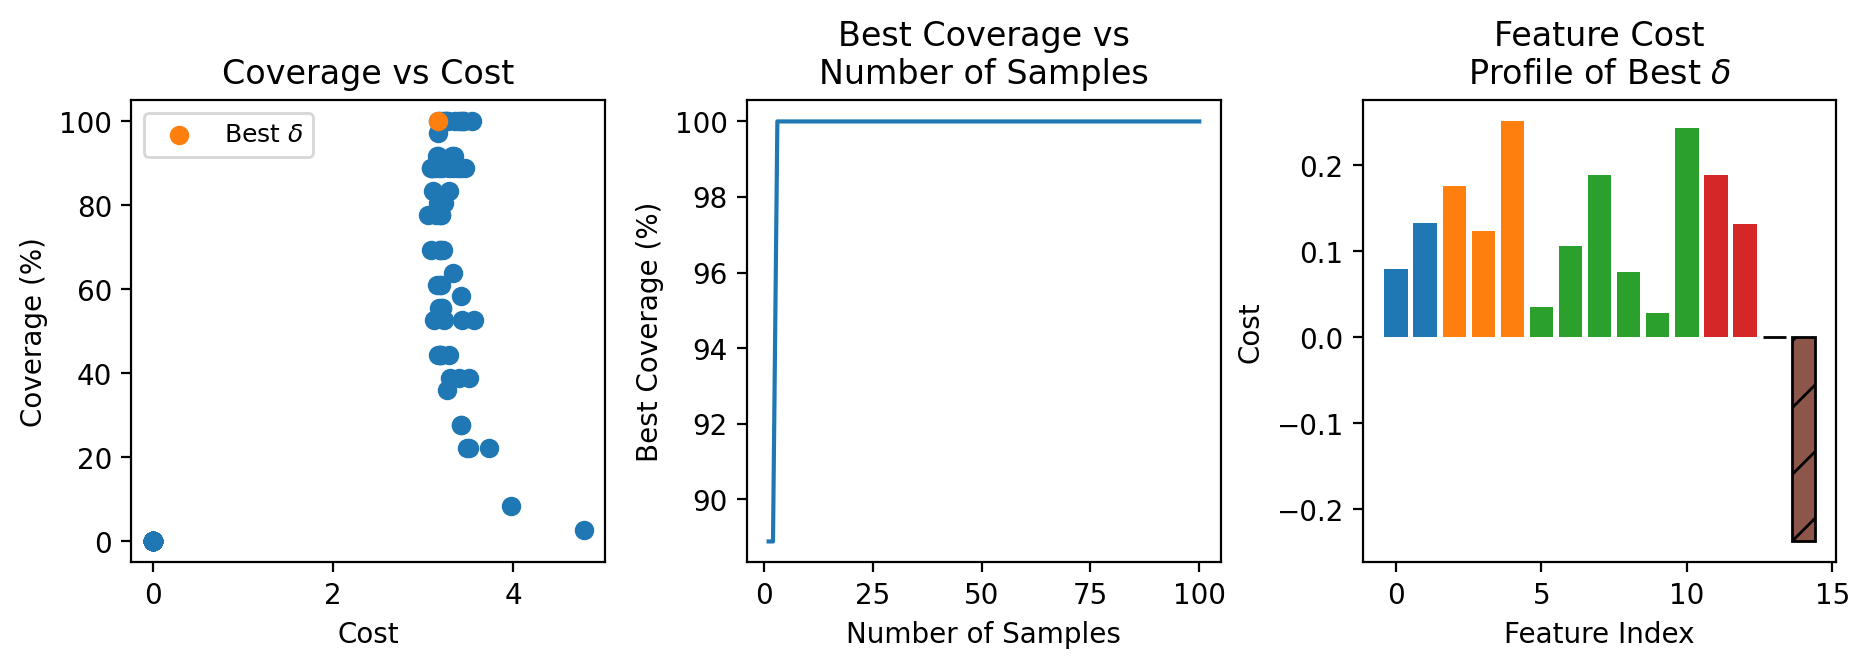

In [18]:
globe_ce.sample(n_sample=sample_num, magnitude=2, sparsity_power=1,  # magnitude is the fixed cost sampled at
                idxs=None, n_features=5, disable_tqdm=False,  # 2 random features chosen at each sample, no sparsity smoothing (p=1)
                plot=True, seed=0, scheme='random', dropped_features=dropped_features)
delta = globe_ce.best_delta  # pick best delta
globe_ce.select_n_deltas(n_div=3)

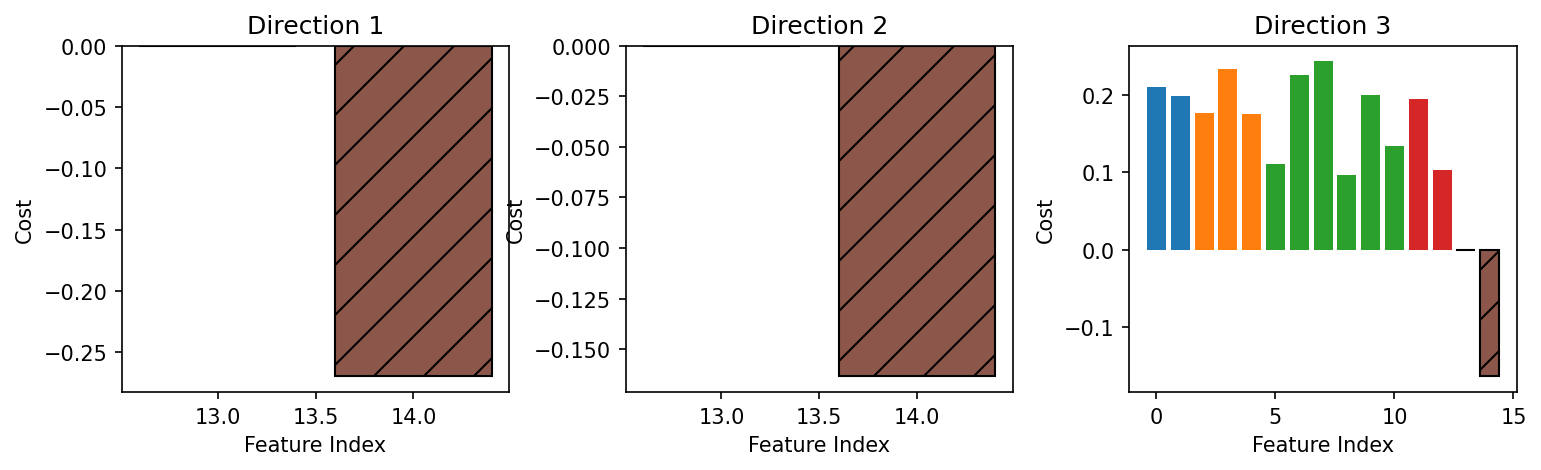

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=globe_ce.deltas_div.shape[0], dpi=150)
fig.set_figwidth(12)
fig.set_figheight(3)
plt.subplots_adjust(wspace=0.3)
for i in range(globe_ce.deltas_div.shape[0]):
    delta_cost = globe_ce.deltas_div[i] * globe_ce.feature_costs_vector
    cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    j, k = 0, 0
    for feature in globe_ce.features_tree:
        if not globe_ce.features_tree[feature]:
            ax[i].bar(range(j, j+1), delta_cost[j], hatch='/',
                        linewidth=1, edgecolor='black', color=cycle[k%len(cycle)])
            j += 1
            k += 1
        else:
            feature_values = globe_ce.features_tree[feature]
            n_f = len(feature_values)
            ax[2].bar(range(j, j+n_f), delta_cost[j:j+n_f], color=cycle[k%len(cycle)])
            j += n_f
            k += 1
    ax[i].set_title(f'Direction {i+1}')
    ax[i].set_xlabel('Feature Index')
    ax[i].set_ylabel('Cost')
plt.show()

In [20]:
n_div = globe_ce.deltas_div.shape[0]
min_costs = np.zeros((n_div, globe_ce.x_aff.shape[0]))
min_costs_idxs = np.zeros((n_div, globe_ce.x_aff.shape[0]))
for i in range(n_div):  # Algorithm 1, Line 2
    cor_s, cos_s, k_s = globe_ce.scale(globe_ce.deltas_div[i], disable_tqdm=False, vector=True)  # Algorithm 1, Line 3
    min_costs[i], min_costs_idxs[i] = globe_ce.min_scalar_costs(cos_s, return_idxs=True, inf=True)  # Implicitly computes Algorithm 1, Lines 4-6, returning minimum costs per input and their indices in the k vector
    max_scalar_idxs = globe_ce.cluster_by_costs(cos_s, n_bins=5)
min_costs = min_costs.min(axis=0)

100%|██████████| 1000/1000 [00:00<00:00, 7949.66it/s]


Unable to find recourse for 0/36 inputs


100%|██████████| 1000/1000 [00:00<00:00, 8311.71it/s]


Unable to find recourse for 0/36 inputs


100%|██████████| 1000/1000 [00:00<00:00, 8315.04it/s]

Unable to find recourse for 0/36 inputs


In [21]:
ces = globe_ce.round_categorical(globe_ce.x_aff+globe_ce.best_delta) if globe_ce.n_categorical else globe_ce.x_aff+globe_ce.best_delta
counterfactual_X_global_ce = pd.DataFrame(ces, columns=X_test.columns)
counterfactual_X_global_ce = postprocessing(counterfactual_X_global_ce)
counterfactual_y_global_ce = model.predict(counterfactual_X_global_ce.values)

C:\Users\Yikai Gu\AppData\Local\Temp\ipykernel_18336\2442358505.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  counterfactual_X = (counterfactual_X>0.5).replace({False:0 ,True:1})


In [22]:
print('Coverage (Globe CE):', counterfactual_y_global_ce.sum()/len(counterfactual_y_global_ce))

Coverage (Globe CE): 1.0


In [23]:
factual_X = df_explain_raw.copy()  # Use the unstandardized sample data for AReS
factual_y = model.predict(factual_X.values)

In [24]:
y_target = torch.ones(factual_X.shape[0])

In [25]:
costs_vector = globe_ce.feature_costs_vector

## AReS

In [26]:
# AReS initiated to determine bin widths for costs
from explainers.ares import AReS
ares = AReS(model=model, dataset=dataset, X=factual_X, n_bins=10, normalise=normalise)  # 1MB

d:\Anaconda\envs\DCE\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Computing Candidate Sets of Conjunctions of Predicates SD and RL
Processing 10 combinations | Sampling itemset size 53
SD and RL Computed with Lengths 65 and 65
Computing Ground Set of Triples V
Reducing RL
RL Reduced from Size 65 to 38


100%|██████████| 65/65 [00:00<00:00, 16229.89it/s]


Ground Set Computed with Length 626


199it [00:00, 566.47it/s]


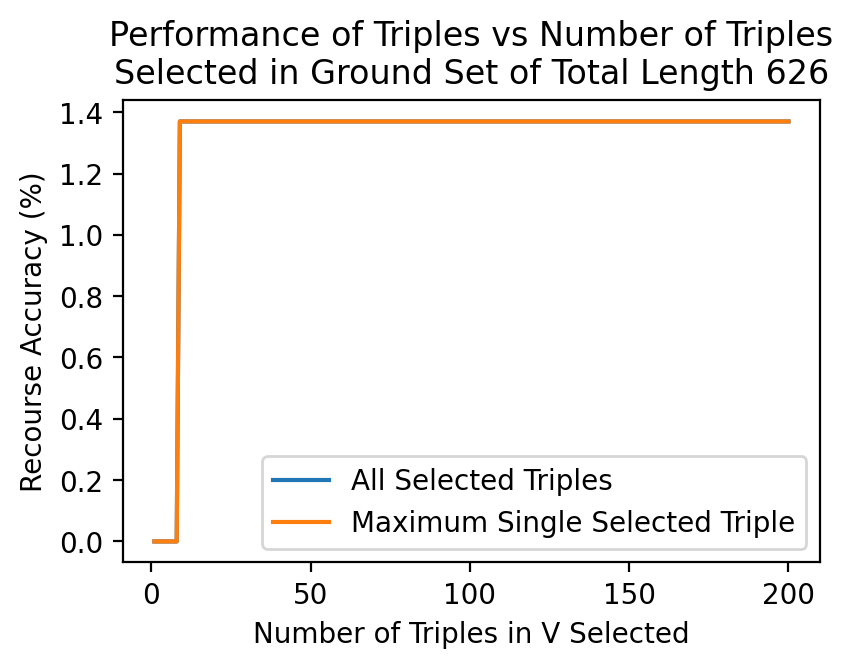

Candidate Set Filtered with Length: 200
Initialising Copy of Ground Set
While there exists a delete/update operation, loop:
Checking Delete
Checking Add


100%|██████████| 199/199 [00:00<00:00, 28427.73it/s]


Checking Exchange


100%|██████████| 199/199 [00:00<00:00, 60060.91it/s]
0it [00:00, ?it/s]


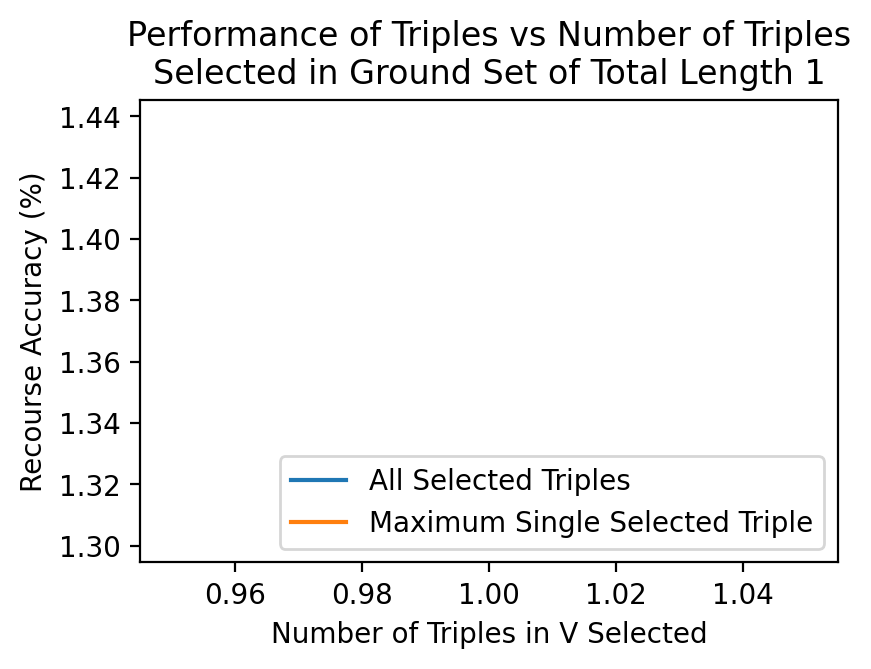

In [27]:
ares.generate_itemsets(apriori_threshold=0.2, max_width=None, # defaults to e2-1
                       affected_subgroup=None, save_copy=False)
# Note: progress bar initial time estimate about 10 times too large
ares.generate_groundset(max_width=None, RL_reduction=True,
                        then_generation=None, save_copy=False)
lams = [1, 0]  # can play around with these lambda values
ares.evaluate_groundset(lams=lams, r=200, save_mode=1,
                        disable_tqdm=False, plot_accuracy=True)
ares.select_groundset(s=200)
ares.optimise_groundset(lams=lams, factor=1, print_updates=False,
                        print_terms=False)

In [28]:
counterfactual_X_ares = pd.DataFrame(ares.R.cfx_matrix[0], columns=X_test.columns)
counterfactual_X_ares = postprocessing(counterfactual_X_ares)
counterfactual_y_ares = model.predict(counterfactual_X_ares.values)

C:\Users\Yikai Gu\AppData\Local\Temp\ipykernel_18336\2442358505.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  counterfactual_X = (counterfactual_X>0.5).replace({False:0 ,True:1})


In [29]:
print('Coverage (AReS):', counterfactual_y_ares.sum()/len(counterfactual_y_ares))

Coverage (AReS): 0.0136986301369863


## Diverse Counterfactual Explanation (DiCE)

In [30]:
backend = 'PYT'  # needs pytorch installed

In [31]:
import dice_ml

m = dice_ml.Model(model=model, backend='PYT')

# Use the same factual_X that was used for other explainers to ensure consistency
# factual_X has the correct dimensions and should match factual_y
factual_X_dice = factual_X.copy()

# Clip extreme values in continuous features to avoid overflow
continuous_features = ['Priors_Count', 'Time_Served']
for feature in continuous_features:
    if feature in factual_X_dice.columns:
        factual_X_dice[feature] = factual_X_dice[feature].clip(-10, 10)

# Ensure factual_y matches the length of factual_X_dice
if len(factual_y) != len(factual_X_dice):
    print(f"⚠️  Adjusting factual_y length from {len(factual_y)} to {len(factual_X_dice)}")
    factual_y_dice = factual_y[:len(factual_X_dice)]
else:
    factual_y_dice = factual_y

factual_X_dice[target_name] = factual_y_dice

# Use all features except the problematic Race categories
dice_features = factual_X_dice.columns.drop([target_name, 'Race = Asian', 'Race = Other']).to_list()

d = dice_ml.Data(dataframe=factual_X_dice, continuous_features=continuous_features, outcome_name = target_name)

dice_explainer = dice_ml.Dice(d, m, method="gradient")

In [32]:
# import os 
# import pickle 
# dump_data_path = './data/baseline/'
# with open(os.path.join(dump_data_path, f"dice_results_{model.name}_{name}.pkl"), 'rb') as file:
#     dice_results = pickle.load(file)

In [33]:
# Generate counterfactuals with error handling for problematic features
try:
    dice_results = dice_explainer.generate_counterfactuals(
        query_instances=factual_X_dice.drop(target_name, axis=1), 
        features_to_vary=dice_features, 
        desired_class="opposite", 
        total_CFs=1
    )
except Exception as e:
    print(f"⚠️  DiCE failed with error: {e}")
    print("🔄 Trying with reduced feature set...")
    
    # Try with only continuous features to avoid categorical issues
    dice_features_reduced = ['Priors_Count', 'Time_Served']
    try:
        dice_results = dice_explainer.generate_counterfactuals(
            query_instances=factual_X_dice.drop(target_name, axis=1), 
            features_to_vary=dice_features_reduced, 
            desired_class="opposite", 
            total_CFs=1
        )
        print("✅ DiCE succeeded with reduced feature set")
    except Exception as e2:
        print(f"❌ DiCE failed even with reduced features: {e2}")
        # Create dummy results for compatibility
        dice_results = None

  1%|          | 1/100 [00:06<09:55,  6.02s/it]

No Counterfactuals found for the given configuation,  perhaps try with different values of proximity (or diversity) weights or learning rate... ; total time taken: 00 min 06 sec


  2%|▏         | 2/100 [00:12<10:33,  6.46s/it]

Diverse Counterfactuals found! total time taken: 00 min 06 sec


  3%|▎         | 3/100 [00:14<06:50,  4.23s/it]

...

Diverse Counterfactuals found! total time taken: 00 min 00 sec


d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\explainer_base.py:596: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.1' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  final_cfs_sparse.at[cf_ix, feature] += np.sign(diff)*change
 99%|█████████▉| 99/100 [05:38<00:00,  1.37it/s]

Diverse Counterfactuals found! total time taken: 00 min 00 sec


100%|██████████| 100/100 [05:44<00:00,  3.45s/it]

No Counterfactuals found for the given configuation,  perhaps try with different values of proximity (or diversity) weights or learning rate... ; total time taken: 00 min 06 sec
✅ DiCE succeeded with reduced feature set


In [34]:
# Process DiCE results with error handling
if dice_results is not None:
    # Iterate through each result and append to the DataFrame
    dice_df_list = []
    for cf in dice_results.cf_examples_list:
        # Convert to DataFrame and append
        cf_df = cf.final_cfs_df
        dice_df_list.append(cf_df)

    counterfactual_X_dice = pd.concat(dice_df_list).reset_index(drop=True).drop(target_name, axis=1)
    counterfactual_X_dice = postprocessing(counterfactual_X_dice)
else:
    print("⚠️  Creating dummy DiCE results for compatibility")
    # Create dummy results with same structure as factual_X
    counterfactual_X_dice = factual_X.copy()
    # Apply small perturbations to continuous features only
    for feature in ['Priors_Count', 'Time_Served']:
        if feature in counterfactual_X_dice.columns:
            counterfactual_X_dice[feature] += np.random.normal(0, 0.1, len(counterfactual_X_dice))
    counterfactual_X_dice = postprocessing(counterfactual_X_dice)

C:\Users\Yikai Gu\AppData\Local\Temp\ipykernel_18336\2442358505.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  counterfactual_X = (counterfactual_X>0.5).replace({False:0 ,True:1})


In [35]:
counterfactual_y_dice = model.predict(counterfactual_X_dice.values)

In [36]:
print('Coverage (DiCE):', counterfactual_y_dice.sum()/len(counterfactual_y_dice))

Coverage (DiCE): 1.0


In [37]:
# import os 
# import pickle 
# dump_data_path = './data/baseline/'
# with open(os.path.join(dump_data_path, f"dice_results_{model.name}_{name}.pkl"), "wb") as file:
#     pickle.dump(dice_results, file)

## Distributional Counterfactual Explanation (DCE)

🎲 Using perturbed initial data (X_init=True)
Results will be saved to: Results\compas\SVM\DCE_np=10,d=1e-05,u1=0.01,u2=0.2,l=0.7,r=0.85,mi=100,tk=1\Gradient_default\seed_42_20250728_163654
📁 Initial data saved:
   - x_true.csv: (100, 15)
   - y_true.csv: (100, 1)
   - y_target.csv: (100,)
Optimization started

--- Iteration 0 ---
U_1 - Qu_upper = 0.010000, U_2 - Qv_upper = -1.114367
eta = 0.8500, interval_left = 0.7075, interval_right = 0.8500
Q = 0.768002, term1 = 0.019667, term2 = 0.900061
best_Q = inf, final_Q = 0.768002

--- Iteration 1 ---
U_1 - Qu_upper = 0.010000, U_2 - Qv_upper = -1.034139
eta = 0.8500, interval_left = 0.7146, interval_right = 0.8500
Q = 0.688849, term1 = 0.026747, term2 = 0.805690
best_Q = inf, final_Q = 0.688849

--- Iteration 2 ---
U_1 - Qu_upper = 0.010000, U_2 - Qv_upper = -0.967348
eta = 0.8500, interval_left = 0.7214, interval_right = 0.8500
Q = 0.625436, term1 = 0.034475, term2 = 0.729723
best_Q = inf, final_Q = 0.625436

--- Iteration 3 ---
U_1 - Qu_up

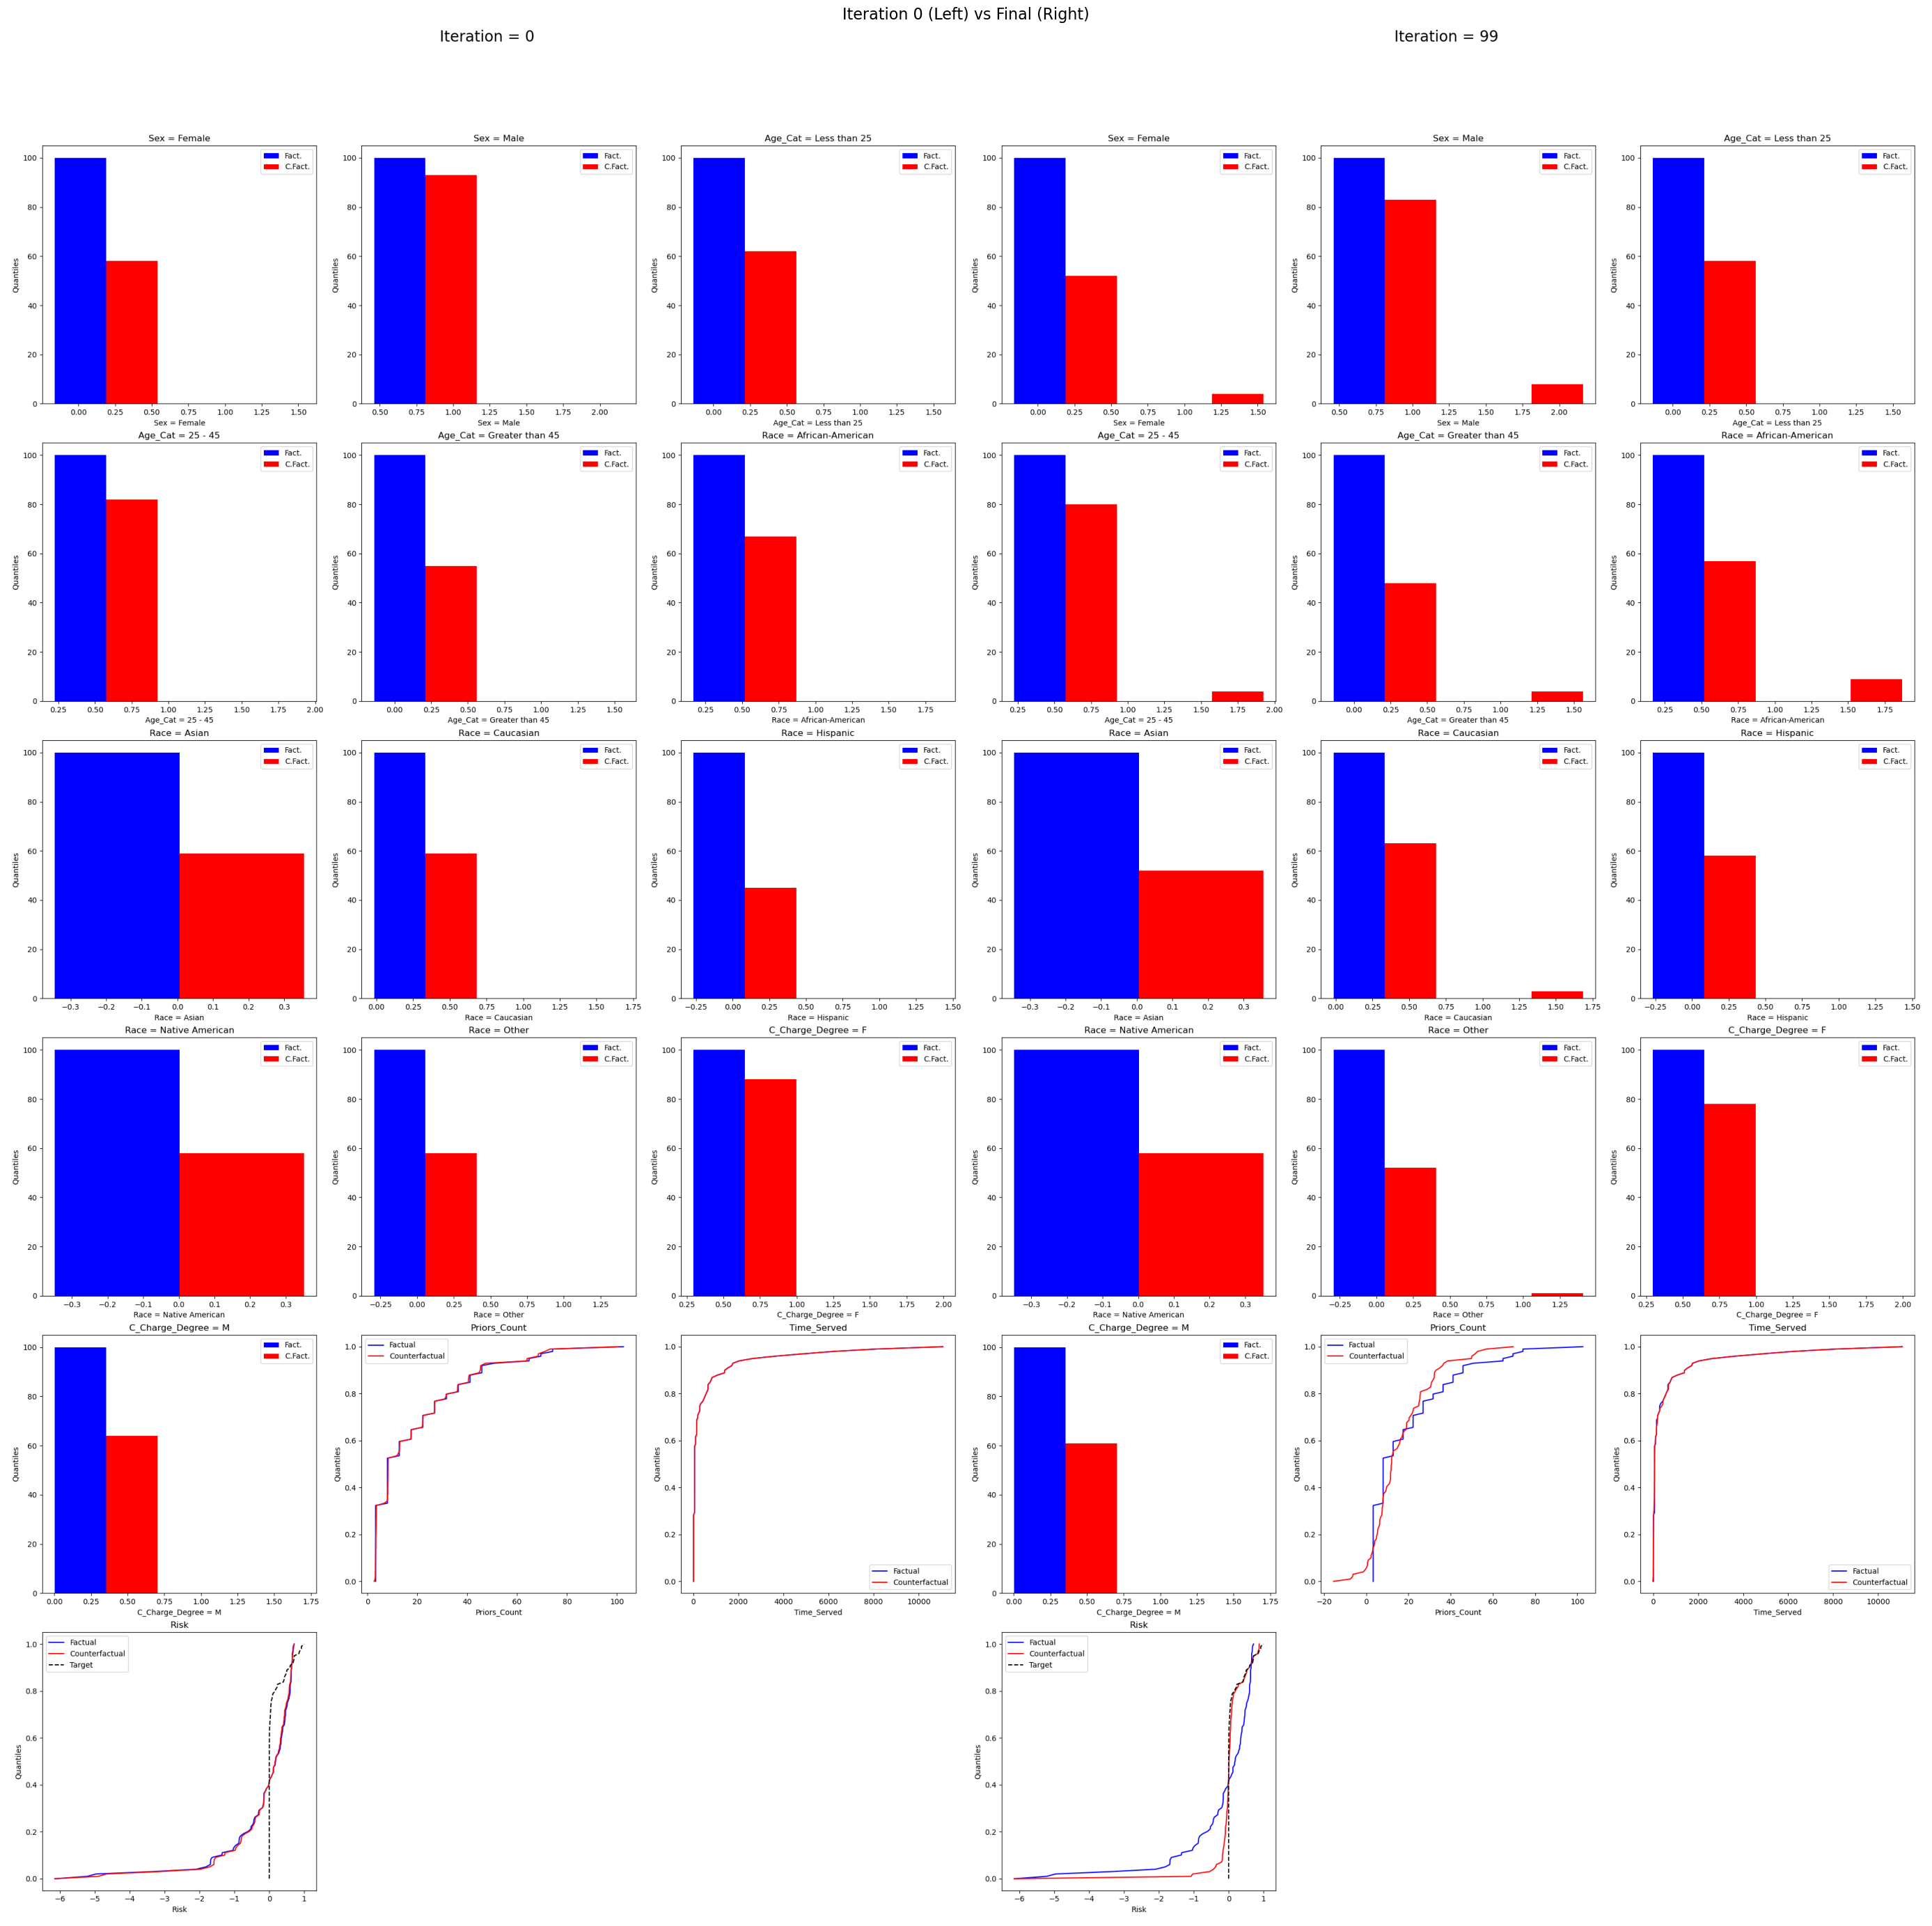

Optimization End
📁 Visualization directory ensured: Results\compas\SVM\DCE_np=10,d=1e-05,u1=0.01,u2=0.2,l=0.7,r=0.85,mi=100,tk=1\Gradient_default\seed_42_20250728_163654\visualizations
Model saved to: Results\compas\SVM\DCE_np=10,d=1e-05,u1=0.01,u2=0.2,l=0.7,r=0.85,mi=100,tk=1\Gradient_default\seed_42_20250728_163654\model.pkl
Error saving results: 'NoneType' object has no attribute 'detach'
✅ DCE Gradient explanation completed!
🎯 Best Q: inf
📊 Final Q: 0.035233


Traceback (most recent call last):
  File "e:\desktop\DCE\explainers\result_saver.py", line 210, in save_results
    best_x_df = pd.DataFrame(explainer.best_X.detach().cpu().numpy(), columns=columns)
                             ^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'detach'


In [ ]:
# Initialize DCE gradient explainer (using latest gradient.py)
from explainers.DCEgradient import DCEExplainerGradient
from explainers.model import Model

# Wrap the model for DCE compatibility
model_wrapped = Model(model=model, backend="pytorch", data=data)

# Initialize the explainer
explainer = DCEExplainerGradient(model_wrapped, data)

# Set df_explain in data object for compatibility
data.df_explain = factual_X
data.sample_num = len(factual_X)

# Run DCE explanation using gradient descent
df_cf_gradient = explainer.explain(
    df_factual=factual_X,
    X_init=True,  # Use perturbed initial data
    n_proj=10,    # N = 10 as in original
    delta=1e-5,   # delta as in original
    U_1=0.01,     # Changed from 0.5 to match demo_new style
    U_2=0.2,      # Changed from 0.2 to match demo_new style  
    l=0.7,        # Changed from 0.7 to match demo_new style
    r=0.85,       # Changed from 0.85 to match demo_new style
    max_iter=100, # max_iter as in original
    callback="full",  # Disable callback for baseline compatibility
    save_results=True,  # Don't save results in baseline
    dataset_name=dataset_name,
    model_name='SVM',
    seed=42
)

print(f"✅ DCE Gradient explanation completed!")
print(f"🎯 Best Q: {explainer.best_Q:.6f}")
print(f"📊 Final Q: {explainer.final_Q:.6f}")

In [ ]:
# import os 
# import pickle 
# dump_data_path = './data/baseline/'
# with open(os.path.join(dump_data_path, f"explainer_{model.name}_{name}.pkl"), 'rb') as file:
#     explainer = pickle.load(file)

In [ ]:
# DCE optimization is now handled in the explainer.explain() call above
# No separate optimization step needed with gradient.py

In [ ]:
# Save step removed - not needed in baseline experiments

In [ ]:
X_train = pd.DataFrame(X_train, columns=X.columns)

In [ ]:
# Process DCE results from gradient.py
counterfactual_X_dce = df_cf_gradient.copy()
counterfactual_X_dce = postprocessing(counterfactual_X_dce)

# Apply data type recovery (same as original)
dtype_dict = X_train.dtypes.apply(lambda x: x.name).to_dict()
for k, v in dtype_dict.items():
    if k in counterfactual_X_dce.columns:
        if v[:3] == 'int':
            counterfactual_X_dce[k] = counterfactual_X_dce[k].round().astype(v)
        else:
            counterfactual_X_dce[k] = counterfactual_X_dce[k].astype(v)

# Get counterfactual predictions
counterfactual_y_prob_dce = pd.DataFrame(
    model.predict(counterfactual_X_dce.values),
    columns=[target_name], 
    index=counterfactual_X_dce.index
)
counterfactual_y_dce = (counterfactual_y_prob_dce.values > 0.5).astype(int).reshape(-1)

In [ ]:
print('Coverage (DCE):', counterfactual_y_dce.sum()/len(counterfactual_y_dce))

## Distance Evaluation

In [ ]:
from explainers.distances import SlicedWassersteinDivergence, WassersteinDivergence
from scipy.stats import gaussian_kde, entropy
from numpy.linalg import LinAlgError

def compute_distance(X_s, X_t):
    if type(X_s) == pd.DataFrame:
        X_s = torch.FloatTensor(X_s.values)
    if type(X_t) == pd.DataFrame:
        X_t = torch.FloatTensor(X_t.values)

    if type(X_s) == np.ndarray:
        X_s = torch.FloatTensor(X_s)
    if type(X_t) == np.ndarray:
        X_t = torch.FloatTensor(X_t)

    if X_s.ndim == 1:
        wd = WassersteinDivergence()
        distance, _ = wd.distance(X_s, X_t, delta=0.1)
    else:
        swd = SlicedWassersteinDivergence(
                dim=X_s.shape[1], n_proj=5000
        )
        distance, _ = swd.distance(X_s, X_t, delta=0.1)
    return distance.item()


def compute_kl_divergence(X_s, X_t):
    kl_divergences = []
    for i in range(X_s.shape[1]):  # Iterate over columns (features)
        try:
            # Estimate probability distributions using KDE
            kde_s = gaussian_kde(X_s[:, i])
            kde_t = gaussian_kde(X_t[:, i])

            # Evaluate the densities on a linear space of the same range
            x_min = min(X_s[:, i].min(), X_t[:, i].min())
            x_max = max(X_s[:, i].max(), X_t[:, i].max())
            x = np.linspace(x_min, x_max, 1000)

            # Compute the KL divergence (entropy)
            kl_div = entropy(kde_s(x), kde_t(x))
        except LinAlgError:
            # Catch the singular matrix error and set the divergence to infinity
            kl_div = np.inf

        kl_divergences.append(kl_div)

    # Aggregate the KL divergences
    total_kl_divergence = np.sum(kl_divergences)  # Or use np.mean for average
    return total_kl_divergence

def gaussian_kernel(x, y, sigma=1.0):
    """Compute the Gaussian kernel between x and y"""
    return np.exp(-np.linalg.norm(x - y) ** 2 / (2 * sigma ** 2))

def mmd(X_s, X_t, kernel=gaussian_kernel):
    """Compute the Maximum Mean Discrepancy (MMD) between two samples X_s and X_t"""
    n = X_s.shape[0]
    m = X_t.shape[0]

    # Calculate the kernel values between all points in the first sample
    XX = np.sum([kernel(X_s[i], X_s[j]) for i in range(n) for j in range(n)])
    
    # Calculate the kernel values between all points in the second sample
    YY = np.sum([kernel(X_t[i], X_t[j]) for i in range(m) for j in range(m)])
    
    # Calculate the kernel values between all points across the two samples
    XY = np.sum([kernel(X_s[i], X_t[j]) for i in range(n) for j in range(m)])

    return XX / (n ** 2) + YY / (m ** 2) - 2 * XY / (n * m)


In [ ]:
cov_ares = counterfactual_y_ares.sum()/len(counterfactual_y_ares)
cov_global_ce = counterfactual_y_global_ce.sum()/len(counterfactual_y_global_ce)
cov_dice = counterfactual_y_dice.sum()/len(counterfactual_y_dice)
cov_dce = counterfactual_y_dce.sum()/len(counterfactual_y_dce)

In [ ]:
print('Coverage (AReS):', cov_ares)
print('Coverage (Globe CE):', cov_global_ce)
print('Coverage (DiCE):', cov_dice)
print('Coverage (DCE):', cov_dce)

In [ ]:
ot_dist_ares = compute_distance(X_s=counterfactual_X_ares, X_t=factual_X)
ot_dist_global_ce = compute_distance(X_s=counterfactual_X_global_ce, X_t=factual_X)
ot_dist_dce = compute_distance(X_s=counterfactual_X_dce, X_t=factual_X)
ot_dist_dice = compute_distance(X_s=counterfactual_X_dice.dropna(), X_t=factual_X)


print('X Distance (AReS):', ot_dist_ares)
print('X Distance (Globe CE):', ot_dist_global_ce)
print('X Distance (DiCE):', ot_dist_dice)
print('X Distance (DCE):', ot_dist_dce)

In [ ]:
print('X MMD (AReS):', mmd(X_s=counterfactual_X_ares.values, X_t=factual_X.values))
print('X MMD (Globe CE):', mmd(X_s=counterfactual_X_global_ce.values, X_t=factual_X.values))
print('X MMD (DiCE):', mmd(X_s=counterfactual_X_dice.dropna().values, X_t=factual_X.values))
print('X MMD (DCE):', mmd(X_s=counterfactual_X_dce.values, X_t=factual_X.values))

In [ ]:
print('X KL-Divergence (AReS):', 
      compute_kl_divergence(X_s=counterfactual_X_ares.values, X_t=factual_X.values))
print('X KL-Divergence (Globe CE):', 
      compute_kl_divergence(X_s=counterfactual_X_global_ce.values, X_t=factual_X.values))
print('X KL-Divergence (DiCE):', 
      compute_kl_divergence(X_s=counterfactual_X_dice.dropna().values, X_t=factual_X.values))
print('X KL-Divergence (DCE):', 
      compute_kl_divergence(X_s=counterfactual_X_dce.values, X_t=factual_X.values))

In [ ]:
ares_diff_pct = []
globe_ce_diff_pct = []
dice_diff_pct = []
dce_diff_pct = []
for column in df_explain.columns:
    ares_pct = (counterfactual_X_ares[column] - factual_X[column]).abs().sum() / (1e-7 + factual_X[column].abs().sum())
    globe_ce_pct = (counterfactual_X_global_ce[column] - factual_X[column]).abs().sum() / (1e-7 + factual_X[column].abs().sum())
    dice_pct = (counterfactual_X_dice[column] - factual_X[column]).abs().sum() / (1e-7 + factual_X[column].abs().sum())
    dce_pct = (counterfactual_X_dce[column] - factual_X[column]).abs().sum() / (1e-7 + factual_X[column].abs().sum())

    ares_diff_pct.append({column: ares_pct})
    globe_ce_diff_pct.append({column: globe_ce_pct})
    dice_diff_pct.append({column: dice_pct})
    dce_diff_pct.append({column: dce_pct})

## Cost Evaluation

In [ ]:
def compute_cost(delta, costs_vector):
    return np.linalg.norm(delta @ np.diag(costs_vector)) 


def compute_absolute_difference(counterfactual_X, factual_X):
    columns = counterfactual_X.columns.drop(['Priors_Count', 'Time_Served'])
    diff_list = []

    for column in columns:
        diff_list.append((counterfactual_X[column] - factual_X[column]).abs().mean())

    return np.nanmean(diff_list)

def compute_statistic_difference(counterfactual_X, factual_X, metric, columns):
    diff_list = []
    for column in columns:
        val_cf = counterfactual_X[column].agg(metric)
        val_f = factual_X[column].agg(metric)
        diff_list.append(abs(val_cf - val_f)/(abs(val_f)) * 100)

    return np.nanmean(diff_list)


In [ ]:
ares_delta = (counterfactual_X_ares - factual_X).dropna().values
globe_ce_delta = (counterfactual_X_global_ce - factual_X).values
dce_delta = (counterfactual_X_dce - factual_X).dropna().values
dice_delta = (counterfactual_X_dice - factual_X).dropna().values
# dice_delta = (counterfactual_X_dice.dropna() - factual_X.loc[counterfactual_X_dice.dropna().index]).values

In [ ]:
print('Cost (AReS):', compute_cost(ares_delta, costs_vector))
print('Cost (Globe CE):', compute_cost(globe_ce_delta, costs_vector))
print('Cost (DiCE):', compute_cost(dice_delta, costs_vector))
print('Cost (DCE):', compute_cost(dce_delta, costs_vector))

In [ ]:
print('Categorical Difference (AReS):', compute_absolute_difference(counterfactual_X_ares, factual_X))
print('Categorical Difference (Globe CE):', compute_absolute_difference(counterfactual_X_global_ce, factual_X))
print('Categorical Difference (DiCE):', compute_absolute_difference(counterfactual_X_dice.dropna(), factual_X))
print('Categorical Difference (DCE):', compute_absolute_difference(counterfactual_X_dce, factual_X))

In [ ]:
metric = 'mean'
columns = ['Priors_Count'] # , 'Time_Served'
print(f'Difference {metric} (AReS):', compute_statistic_difference(counterfactual_X_ares, factual_X, metric,columns))
print(f'Difference {metric} (Globe CE):', compute_statistic_difference(counterfactual_X_global_ce, factual_X, metric,columns))
print(f'Difference {metric} (DiCE):', compute_statistic_difference(counterfactual_X_dice, factual_X, metric,columns))
print(f'Difference {metric} (DCE):', compute_statistic_difference(counterfactual_X_dce, factual_X, metric,columns))

In [ ]:
metric = 'std'
columns = ['Priors_Count'] # , 'Time_Served'
print(f'Difference {metric} (AReS):', compute_statistic_difference(counterfactual_X_ares, factual_X, metric,columns))
print(f'Difference {metric} (Globe CE):', compute_statistic_difference(counterfactual_X_global_ce, factual_X, metric,columns))
print(f'Difference {metric} (DiCE):', compute_statistic_difference(counterfactual_X_dice, factual_X, metric,columns))
print(f'Difference {metric} (DCE):', compute_statistic_difference(counterfactual_X_dce, factual_X, metric,columns))

In [ ]:
metric = 'mean'
columns = ['Time_Served'] # , 'Time_Served'
print(f'Difference {metric} (AReS):', compute_statistic_difference(counterfactual_X_ares, factual_X, metric,columns))
print(f'Difference {metric} (Globe CE):', compute_statistic_difference(counterfactual_X_global_ce, factual_X, metric,columns))
print(f'Difference {metric} (DiCE):', compute_statistic_difference(counterfactual_X_dice, factual_X, metric,columns))
print(f'Difference {metric} (DCE):', compute_statistic_difference(counterfactual_X_dce, factual_X, metric,columns))

In [ ]:
metric = 'std'
columns = ['Time_Served'] # , 'Time_Served'
print(f'Difference {metric} (AReS):', compute_statistic_difference(counterfactual_X_ares, factual_X, metric,columns))
print(f'Difference {metric} (Globe CE):', compute_statistic_difference(counterfactual_X_global_ce, factual_X, metric,columns))
print(f'Difference {metric} (DiCE):', compute_statistic_difference(counterfactual_X_dice, factual_X, metric,columns))
print(f'Difference {metric} (DCE):', compute_statistic_difference(counterfactual_X_dce, factual_X, metric,columns))

## Diversity

In [ ]:
def compute_average_pairwise_distance(counterfactual_X):
    n = len(counterfactual_X)
    total_distance = 0
    count = 0

    for i in range(n):
        for j in range(i+1, n):
            dist = np.linalg.norm(counterfactual_X.iloc[i] - counterfactual_X.iloc[j])
            total_distance += dist
            count += 1

    if count > 0:
        average_distance = total_distance / count
    else:
        average_distance = 0

    return average_distance


In [ ]:
diversity_factual = compute_average_pairwise_distance(factual_X)

In [ ]:
print('Diversity (Factual)', diversity_factual)

In [ ]:
diversity_ares = compute_average_pairwise_distance(counterfactual_X_ares)
diversity_global_ce = compute_average_pairwise_distance(counterfactual_X_global_ce)
diversity_dice = compute_average_pairwise_distance(counterfactual_X_dice.dropna())
diversity_dce = compute_average_pairwise_distance(counterfactual_X_dce)

In [ ]:
print('Diversity (AReS):', diversity_ares)
print('Diversity (Globe CE):', diversity_global_ce)
print('Diversity (DiCE):', diversity_dice)
print('Diversity (DCE):', diversity_dce)

In [ ]:
print('Effective Diversity (AReS):', diversity_ares/ot_dist_ares * cov_ares)
print('Effective Diversity (Globe CE):', diversity_global_ce/ot_dist_global_ce * cov_global_ce)
print('Effective Diversity (DiCE):', diversity_dice/ot_dist_dice * cov_dice)
print('Effective Diversity (DCE):', diversity_dce/ot_dist_dce * cov_dce)